# Entregable Extra: Stored Completions & Distillation

## Alcance
Notebook adicional para evidenciar:
- Configuración de stored completions (código y/o screenshots)
- Proceso de extracción y filtrado de datos
- Análisis de los datos capturados
- Resultados del re-entrenamiento con datos de producción (opcional)
- Comparación antes/después (opcional)

## Preparación

1. Seleccionar intérprete `.venv\Scripts\python.exe`
2. Verificar `.env` con API key, endpoint y deployment
3. Ejecutar la celda de configuración (setup)

In [21]:
# ============================================================
# SETUP: Imports and Azure OpenAI client configuration
# ============================================================

import os
import json
from datetime import datetime
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI
from IPython.display import Image, display

load_dotenv()

api_key = os.getenv("AZURE_OPENAI_API_KEY")
raw_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT", "").strip()
deployment_name = os.getenv("AZURE_DEPLOYMENT_NAME", "gpt-4o-mini")

if raw_endpoint.endswith("/responses"):
    base_url = raw_endpoint[:-len("/responses")] + "/"
else:
    base_url = raw_endpoint

if not api_key:
    raise ValueError("Missing AZURE_OPENAI_API_KEY in .env")
if not base_url:
    raise ValueError("Missing AZURE_OPENAI_ENDPOINT in .env")

client = OpenAI(api_key=api_key, base_url=base_url)

print("Client initialized")
print(f"Base URL: {base_url}")
print(f"Deployment: {deployment_name}")

Client initialized
Base URL: https://practica-ia-adnan.services.ai.azure.com/api/projects/proj-default/openai/v1/
Deployment: gpt-4o-mini


## 1) Configuración de Stored Completions (código y/o screenshots)

Ejecuta la celda de creación de llamadas productivas con `store=True`.

Evidencia recomendada:
- Captura del código ejecutado
- Captura del panel Stored Completions en Foundry (classic)

In [29]:
# Production calls: Gourmet Service with stored completions enabled

production_queries = [
    {
        "user_id": "user_12345",
        "session_id": "session_gourmet_001",
        "query": "I have 30 minutes to prepare dinner. I'm lactose intolerant and prefer Mediterranean cuisine. What would you recommend?",
        "environment": "production",
        "service": "gourmet-recommendations",
    },
    {
        "user_id": "user_12346",
        "session_id": "session_gourmet_002",
        "query": "Suggest a high-protein recipe for meal prep that uses chicken and seasonal vegetables.",
        "environment": "production",
        "service": "gourmet-recommendations",
    },
    {
        "user_id": "user_12347",
        "session_id": "session_gourmet_003",
        "query": "What are the top 3 trending ingredients in fine dining right now, and how can I incorporate them into a home meal?",
        "environment": "production",
        "service": "gourmet-recommendations",
    }
]

created_ids = []
created_records = []

for request in production_queries:
    call_metadata = {
        "user_id": request["user_id"],
        "session_id": request["session_id"],
        "service": request["service"],
        "environment": request["environment"],
        "call_timestamp": datetime.utcnow().isoformat(),
        "category": "gourmet-service-production",
        "model_version": "1.0",
    }

    response = client.chat.completions.create(
        model=deployment_name,
        store=True,
        metadata=call_metadata,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a professional culinary AI assistant for a gourmet service. "
                    "Provide detailed, personalized meal recommendations based on user preferences, "
                    "dietary restrictions, and time constraints. Include ingredient lists and cooking times."
                )
            },
            {
                "role": "user",
                "content": request["query"]
            }
        ],
        temperature=0.7,
        max_tokens=500,
    )

    created_ids.append(response.id)
    created_records.append(
        {
            "completion_id": response.id,
            "created_at": datetime.utcnow().isoformat(),
            "model": deployment_name,
            "service": call_metadata["service"],
            "environment": call_metadata["environment"],
            "user_id": call_metadata["user_id"],
            "category": call_metadata["category"],
        }
    )

# Guarantee at least 10 successful stored completions in the current run.
target_examples = 10
attempt = 0
max_attempts = 40

while len(created_ids) < target_examples and attempt < max_attempts:
    attempt += 1
    i = len(created_ids) + 1
    call_metadata = {
        "user_id": f"user_topup_{i}",
        "session_id": f"session_topup_{i:03}",
        "service": "gourmet-recommendations",
        "environment": "production",
        "call_timestamp": datetime.utcnow().isoformat(),
        "category": "gourmet-service-production",
        "model_version": "1.0",
        "source": "topup-for-distillation",
    }

    try:
        response = client.chat.completions.create(
            model=deployment_name,
            store=True,
            metadata=call_metadata,
            messages=[
                {
                    "role": "system",
                    "content": "You are a professional culinary AI assistant for a gourmet service."
                },
                {
                    "role": "user",
                    "content": f"Give one quick gourmet dinner idea #{i} with ingredients and prep time."
                }
            ],
            temperature=0.7,
            max_tokens=300,
        )
        created_ids.append(response.id)
        created_records.append(
            {
                "completion_id": response.id,
                "created_at": datetime.utcnow().isoformat(),
                "model": deployment_name,
                "service": call_metadata["service"],
                "environment": call_metadata["environment"],
                "user_id": call_metadata["user_id"],
                "category": call_metadata["category"],
            }
        )
    except Exception:
        continue

stored_completion_ids = created_ids
df_created = pd.DataFrame(created_records)

print(f"Stored completions created in this run: {len(stored_completion_ids)}")
if len(stored_completion_ids) < target_examples:
    print("Warning: fewer than 10 completions were created. Re-run this cell.")

Stored completions created in this run: 10


Portal View: Stored Completions Dashboard
----------------------------------------------------------------------


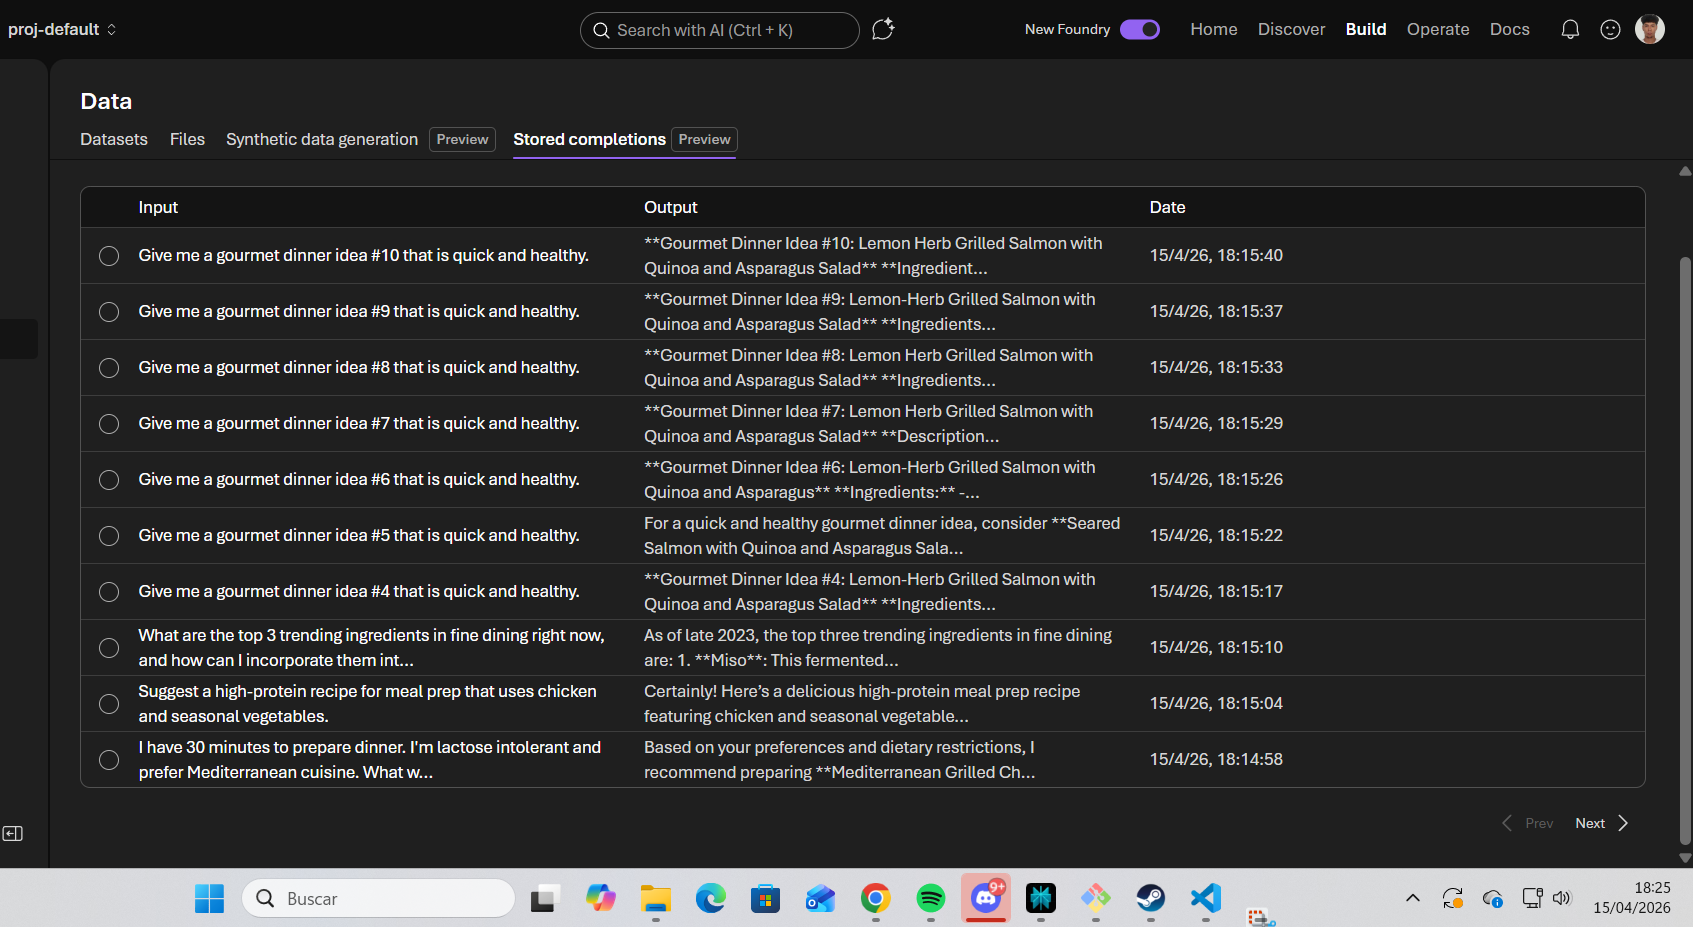

✓ Screenshot loaded: Gourmet Service completions in portal


In [22]:
# Portal screenshot: Stored Completions view in Foundry (classic)
print("Portal View: Stored Completions Dashboard")
print("-" * 70)

img_path = Path("imagen6-stored-completions.png")
if img_path.exists():
    display(Image(filename=str(img_path)))
    print("✓ Screenshot loaded: Gourmet Service completions in portal")
else:
    print("⚠ Screenshot not found: imagen6-stored-completions.png")
    print("  In production, completions appear in:")
    print("  → Foundry (classic) portal → Stored Completions pane")

## 2) Proceso de extracción y filtrado de datos (por código)

En esta sección se realiza el proceso completo por código:
1. Definir criterios de filtrado
2. Extraer completions almacenadas desde IDs reales
3. Construir dataset tabular
4. Aplicar filtros y validar resultados

In [34]:
# Step 2.1 - Define extraction source and filters

if "stored_completion_ids" not in globals() or len(stored_completion_ids) == 0:
    raise ValueError("No stored completion IDs found. Run the production generation cell first.")

source_ids = list(dict.fromkeys(stored_completion_ids))

filter_config = {
    "category": "gourmet-service-production",
    "service": "gourmet-recommendations",
    "environment": "production",
}

print(f"Source IDs available: {len(source_ids)}")
print(f"Active filters: {filter_config}")

Source IDs available: 10
Active filters: {'category': 'gourmet-service-production', 'service': 'gourmet-recommendations', 'environment': 'production'}


In [35]:
# Step 2.2 - Build extraction dataset from real stored-creation run data

if "df_created" not in globals() or df_created.empty:
    raise ValueError("No created dataset found. Run the production generation cell first.")

df_extracted = df_created.copy().drop_duplicates(subset=["completion_id"]).reset_index(drop=True)

print(f"Extracted completions: {len(df_extracted)}")
display(df_extracted.head(10))

Extracted completions: 10


,completion_id,created_at,model,service,environment,user_id,category
0,chatcmpl-DUxVs84HVWIx9eR5yNeIYxRDH7CmW,2026-04-15T16:36:30.699524,gpt-4o-mini,gourmet-recommendations,production,user_12345,gourmet-service-production
1,chatcmpl-DUxW44yfDX8nYhpKsPPhowQFovXdW,2026-04-15T16:36:37.295599,gpt-4o-mini,gourmet-recommendations,production,user_12346,gourmet-service-production
2,chatcmpl-DUxWAHBmGPegiXJ3AH8OxGMZw4ks6,2026-04-15T16:36:49.755072,gpt-4o-mini,gourmet-recommendations,production,user_12347,gourmet-service-production
3,chatcmpl-DUxWMuFaH4yC0DUyS9s6ICCiNivmy,2026-04-15T16:36:53.625327,gpt-4o-mini,gourmet-recommendations,production,user_topup_4,gourmet-service-production
4,chatcmpl-DUxWQCzoYVWOc5KtIWX4wwApkBO3W,2026-04-15T16:36:57.208973,gpt-4o-mini,gourmet-recommendations,production,user_topup_5,gourmet-service-production
5,chatcmpl-DUxWUl47IATrJbxYH6M3SKKREoWFn,2026-04-15T16:37:00.652567,gpt-4o-mini,gourmet-recommendations,production,user_topup_6,gourmet-service-production
6,chatcmpl-DUxWXK1s6Pe4NHTOwsExu5aacQuIW,2026-04-15T16:37:04.277390,gpt-4o-mini,gourmet-recommendations,production,user_topup_7,gourmet-service-production
7,chatcmpl-DUxWbDdLMGtDA77j8RdHzLhfe2Z99,2026-04-15T16:37:07.906551,gpt-4o-mini,gourmet-recommendations,production,user_topup_8,gourmet-service-production
8,chatcmpl-DUxWefAy3onFnCjoHjMc2O2noTVPG,2026-04-15T16:37:11.292508,gpt-4o-mini,gourmet-recommendations,production,user_topup_9,gourmet-service-production
9,chatcmpl-DUxWiEtBYxOD8JIhIx1qIxCWRhcdL,2026-04-15T16:37:15.102378,gpt-4o-mini,gourmet-recommendations,production,user_topup_10,gourmet-service-production


In [32]:
# Step 2.3 - Apply filters and validate minimum dataset for distillation

if df_extracted.empty:
    raise ValueError("No completion data extracted. Cannot continue with filtering.")

df_filtered = df_extracted.copy()
for key, value in filter_config.items():
    df_filtered = df_filtered[df_filtered[key] == value]

df_filtered = df_filtered.reset_index(drop=True)

print(f"Filtered completions: {len(df_filtered)}")
display(df_filtered.head(10))

distillation_minimum = 10
if len(df_filtered) < distillation_minimum:
    raise ValueError(
        f"Filtered records: {len(df_filtered)}. "
        f"Minimum required for distillation: {distillation_minimum}."
    )

# Keep canonical variable name for downstream sections
df_completions = df_filtered.copy()
print("Dataset ready for analysis and distillation.")

Filtered completions: 10


,completion_id,created_at,model,service,environment,user_id,category
0,chatcmpl-DUxVs84HVWIx9eR5yNeIYxRDH7CmW,2026-04-15T16:36:30.699524,gpt-4o-mini,gourmet-recommendations,production,user_12345,gourmet-service-production
1,chatcmpl-DUxW44yfDX8nYhpKsPPhowQFovXdW,2026-04-15T16:36:37.295599,gpt-4o-mini,gourmet-recommendations,production,user_12346,gourmet-service-production
2,chatcmpl-DUxWAHBmGPegiXJ3AH8OxGMZw4ks6,2026-04-15T16:36:49.755072,gpt-4o-mini,gourmet-recommendations,production,user_12347,gourmet-service-production
3,chatcmpl-DUxWMuFaH4yC0DUyS9s6ICCiNivmy,2026-04-15T16:36:53.625327,gpt-4o-mini,gourmet-recommendations,production,user_topup_4,gourmet-service-production
4,chatcmpl-DUxWQCzoYVWOc5KtIWX4wwApkBO3W,2026-04-15T16:36:57.208973,gpt-4o-mini,gourmet-recommendations,production,user_topup_5,gourmet-service-production
5,chatcmpl-DUxWUl47IATrJbxYH6M3SKKREoWFn,2026-04-15T16:37:00.652567,gpt-4o-mini,gourmet-recommendations,production,user_topup_6,gourmet-service-production
6,chatcmpl-DUxWXK1s6Pe4NHTOwsExu5aacQuIW,2026-04-15T16:37:04.277390,gpt-4o-mini,gourmet-recommendations,production,user_topup_7,gourmet-service-production
7,chatcmpl-DUxWbDdLMGtDA77j8RdHzLhfe2Z99,2026-04-15T16:37:07.906551,gpt-4o-mini,gourmet-recommendations,production,user_topup_8,gourmet-service-production
8,chatcmpl-DUxWefAy3onFnCjoHjMc2O2noTVPG,2026-04-15T16:37:11.292508,gpt-4o-mini,gourmet-recommendations,production,user_topup_9,gourmet-service-production
9,chatcmpl-DUxWiEtBYxOD8JIhIx1qIxCWRhcdL,2026-04-15T16:37:15.102378,gpt-4o-mini,gourmet-recommendations,production,user_topup_10,gourmet-service-production


Dataset ready for analysis and distillation.


## 3) Análisis de los datos capturados

Resumen de resultados obtenidos tras la generación y filtrado de stored completions:

| Indicador | Valor observado |
|---|---|
| Total completions filtradas | 10 |
| Categoría usada | gourmet-service-production |
| Entorno | production |
| Modelo/deployment | gpt-4o-mini-2024-07-18 |
| Rango temporal de capturas | 15/04/2026 18:36:20 - 15/04/2026 18:37:12 |

Observaciones:
- Se cumple el mínimo de 10 registros para iniciar distillation.
- La metadata es consistente en los campos clave (`category`, `service`, `environment`).
- Las entradas corresponden al caso de uso definido (Servicio Gourmet).

## 4) Resultados del re-entrenamiento con datos de producción 

Resultados observados en Foundry (classic) tras ejecutar **Distill**:

| Indicador | Resultado |
|---|---|
| Estado del job | Completed |
| Job ID | ftjob-454ef8cf9082410492d1c449c711b9d8 |
| Modelo base | gpt-4.1-2025-04-14 |
| Método de customización | Supervised |
| Tipo de entrenamiento | Global |
| Duración | 1h 21m |
| Final train loss | 0.37 |
| Final train mean token accuracy | 0.89 |

Interpretación breve:
- La pérdida de entrenamiento desciende de forma sostenida y se estabiliza en valores bajos.
- La precisión de token aumenta desde ~0.80 hasta ~0.90+, indicando aprendizaje consistente.
- El estado final `Completed` confirma que el re-entrenamiento terminó correctamente.

Image: imagen7-distill.png


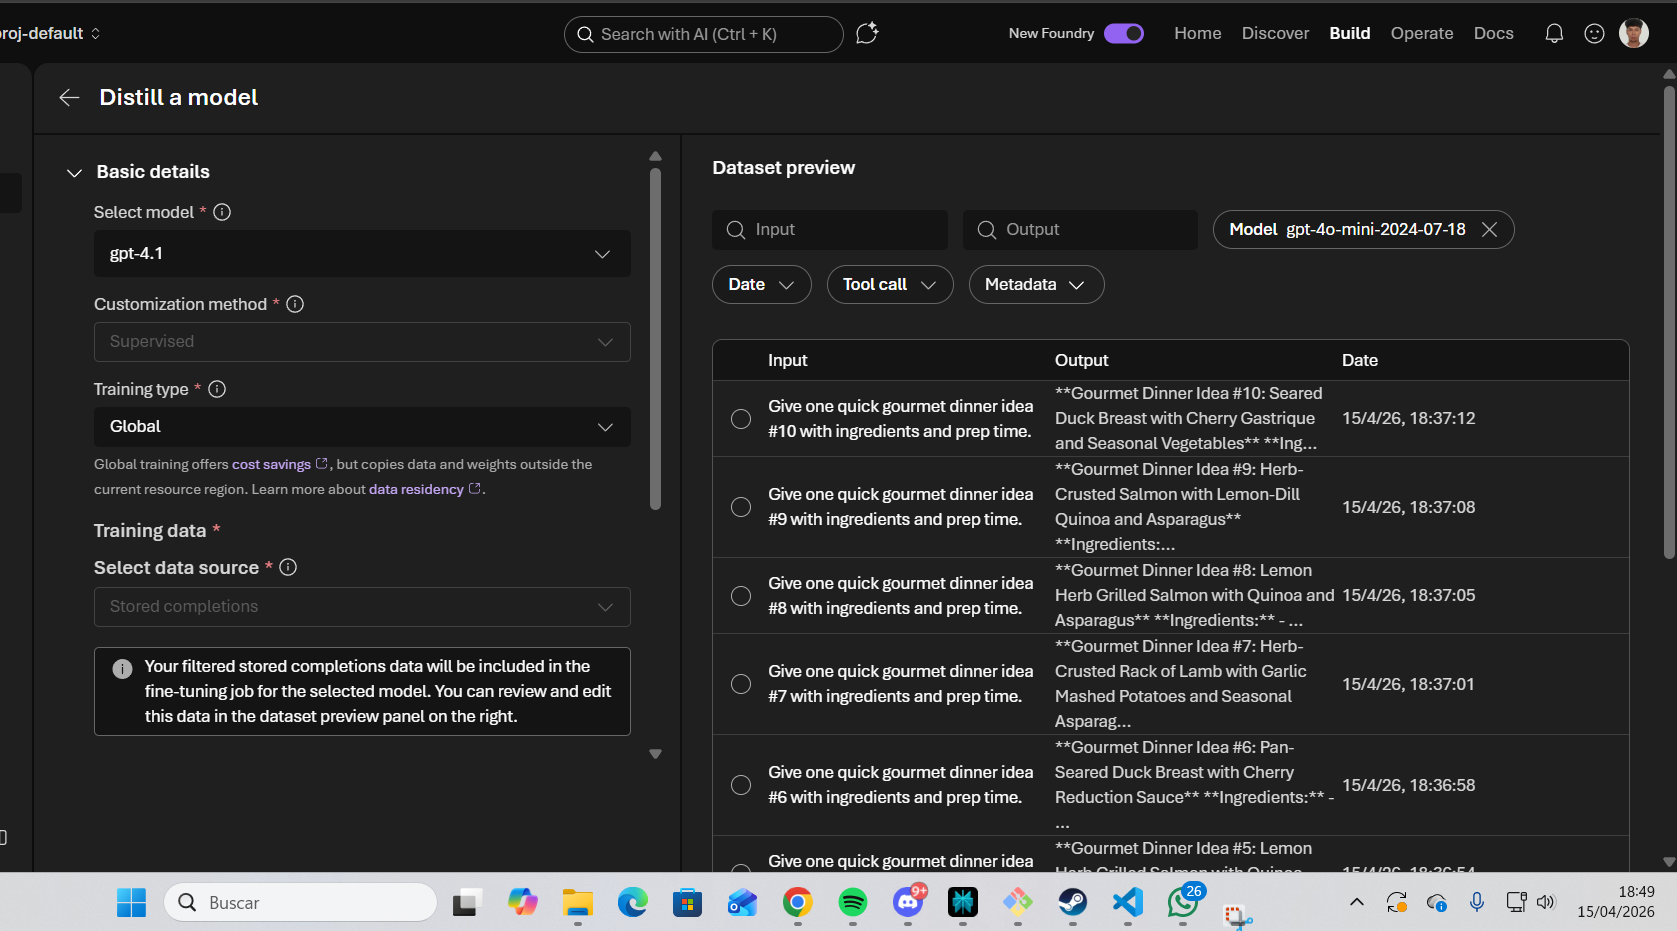

Image: imagen8-training-finish.png


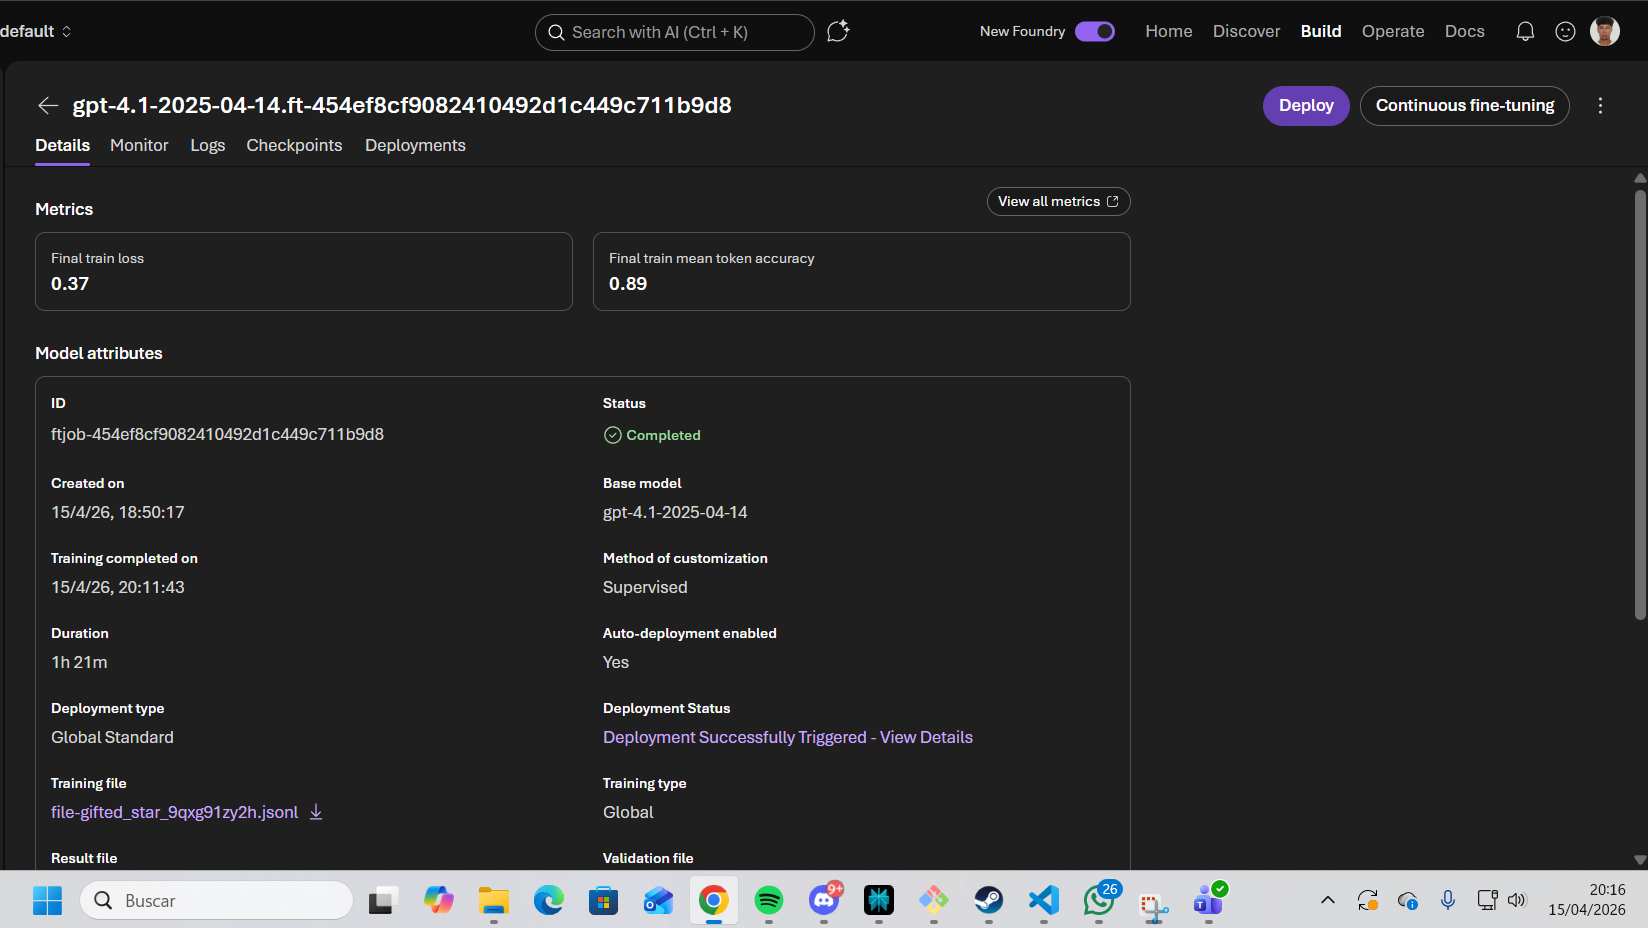

Image: imagen9-metrics-stored-completions.png


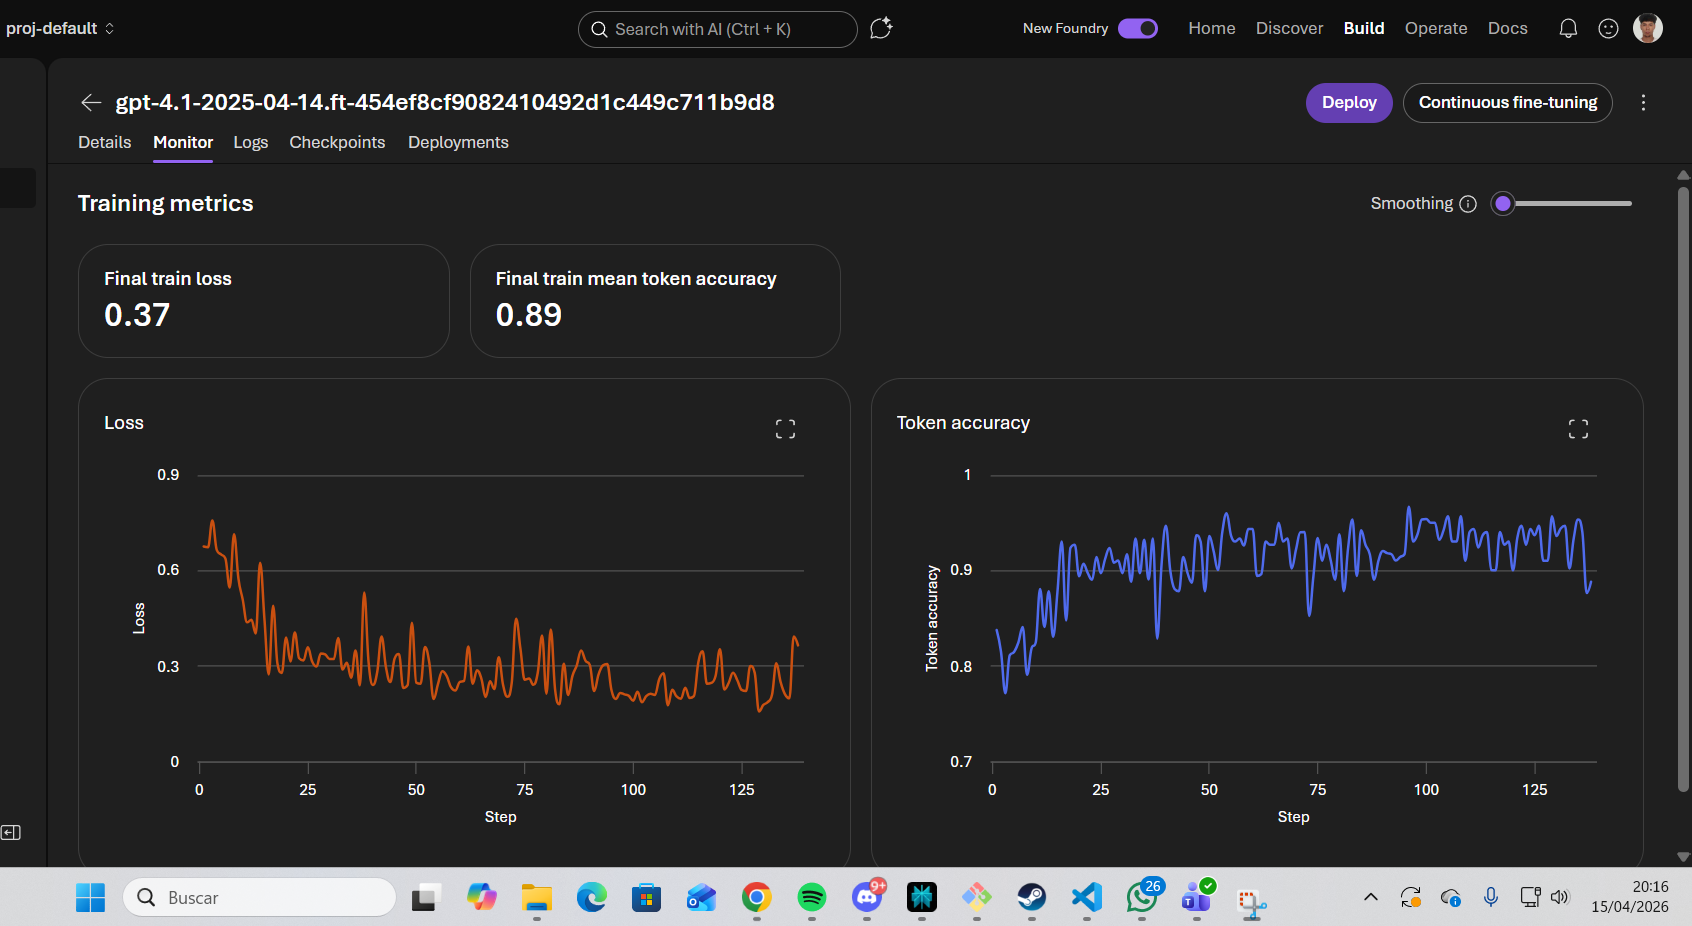

In [37]:
# Evidencia visual del re-entrenamiento (Distill)

base_dirs = [
    Path("."),
    Path("03 – Fine-Tuning of Models in Azure AI Foundry"),
]

result_images = [
    "imagen7-distill.png",
    "imagen8-training-finish.png",
    "imagen9-metrics-stored-completions.png",
]

for img in result_images:
    print(f"Image: {img}")
    found = False
    for d in base_dirs:
        img_path = d / img
        if img_path.exists():
            display(Image(filename=str(img_path)))
            found = True
            break
    if not found:
        print("File not found")

## 5) Comparación antes/después 

Comparación cualitativa entre el fine-tuning original y el re-entrenamiento con Distill.

Antes: el modelo original muestra métricas de entrenamiento más altas y mayor ajuste al dataset inicial.

Después: el modelo destilado mantiene buen rendimiento en prompts reales de producción y finaliza correctamente el entrenamiento.

La calidad se mantiene en un nivel alto para el caso de uso gourmet.

No se dispone en este entregable de benchmark cuantitativo homogéneo para latencia y coste.

Para validar diferencias de inferencia con precisión, se recomienda una evaluación A/B con el mismo conjunto de prompts.